In [ ]:
# importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

weatherAus = pd.read_csv(r"data\weatherAUS.csv")

In [2]:
weatherAus.shape

(145460, 23)

In [72]:
# Feature Engineering

In [3]:
weatherAus['Date'] = pd.to_datetime(weatherAus['Date'])
def add_dateparts(df , col):
    df[col + '_year'] = df[col].dt.year
    df[col + '_month'] = df[col].dt.month
    df[col + '_day'] = df[col].dt.day

colm = 'Date'

add_dateparts(weatherAus , colm)

In [4]:
weatherAus['Date_week'] = weatherAus['Date'].dt.isocalendar().week.astype(int)
weatherAus['Date_dayofyear'] = weatherAus['Date'].dt.day_of_year
weatherAus['Date_weekend'] = (weatherAus['Date'].dt.day_of_week >= 5).astype(int)

In [5]:
weatherAus.drop('Date', axis=1 , inplace=True)

In [6]:
weatherAus['RainToday'] = weatherAus['RainToday'].map({"No": 0 , "Yes" : 1})
weatherAus['RainTomorrow'] = weatherAus['RainTomorrow'].map({"No": 0 , "Yes" : 1})

In [7]:
numeric_cols = [ 'MinTemp',	'MaxTemp' , 'Rainfall' , 'Evaporation' , 'Sunshine'	,
                'WindGustSpeed' ,'WindSpeed9am','WindSpeed3pm' ,'Humidity9am' ,'Humidity3pm',	
                'Pressure9am',	'Pressure3pm',	'Cloud9am',	'Cloud3pm',	'Temp9am',	'Temp3pm' , 'RainToday',
                'Date_year', 'Date_month' , 'Date_day', 'Date_week', 'Date_dayofyear', 'Date_weekend']

categorical_cols = ['Location' , 'WindGustDir' , 'WindDir9am' , 'WindSpeed3pm']


In [73]:
# Train , Validation , Test split

In [8]:
train_df = weatherAus[(weatherAus['Date_year'] >= 2007) & (weatherAus['Date_year'] <= 2014)]
val_df = weatherAus[(weatherAus['Date_year'] >= 2015) & (weatherAus['Date_year'] <= 2016)]
test_df = weatherAus[(weatherAus['Date_year'] == 2017)]

In [11]:
train_df = train_df.dropna(subset=['RainTomorrow'])
val_df = val_df.dropna(subset=['RainTomorrow'])
test_df = test_df.dropna(subset=['RainTomorrow'])

In [12]:
x_train = train_df.drop('RainTomorrow' , axis=1)
y_train = train_df['RainTomorrow']

x_val = val_df.drop('RainTomorrow', axis=1)
y_val = val_df['RainTomorrow']

x_test = test_df.drop('RainTomorrow', axis=1)
y_test = test_df['RainTomorrow']

In [15]:
# INTRODUCING PIPELINE


In [16]:
# NUMERICAL

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')) ,
    ('scaler' , StandardScaler())
])

In [17]:
# CATEGORICAL

from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')) ,
    ('encoder' , OneHotEncoder(handle_unknown='ignore' ))
])

In [18]:
# COMBINED

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num' , numeric_pipeline , numeric_cols) ,
    ('cat' , categorical_pipeline , categorical_cols)
])

In [19]:
# Evaluation Function

In [20]:
from sklearn.metrics import (
    accuracy_score ,
    precision_score ,
    recall_score ,
    f1_score ,
    roc_auc_score ,
    confusion_matrix ,
    classification_report, 
    ConfusionMatrixDisplay ,
    RocCurveDisplay ,
    PrecisionRecallDisplay
)

In [21]:
def evaluate_model(model , x_train , y_train , x_val , y_val):

    # Train
    model.fit(x_train , y_train)

    # Predictions
    y_train_pred = model.predict(x_train)
    y_val_pred = model.predict(x_val)

    # Prob scores for ROC-AUC and curves
    y_train_prob = model.predict_proba(x_train)[:,1]
    y_val_prob = model.predict_proba(x_val)[:,1]

    # Metrices
    train_accuracy = accuracy_score(y_train , y_train_pred)
    val_accuracy = accuracy_score(y_val , y_val_pred)

    train_precision = precision_score(y_train , y_train_pred)
    val_precision = precision_score(y_val , y_val_pred)

    train_recall = recall_score(y_train , y_train_pred)
    val_recall = recall_score(y_val , y_val_pred)

    train_f1 = f1_score(y_train , y_train_pred)
    val_f1 = f1_score(y_val , y_val_pred)

    train_roc_auc = roc_auc_score(y_train , y_train_prob)
    val_roc_auc = roc_auc_score(y_val , y_val_prob)

    # Print Results
    print("TRAIN RESULTS")
    print("---------------")
    print(f"Accuracy = {train_accuracy:.4f}")
    print(f"Precision = {train_precision:.4f}")
    print(f"Recall = {train_recall:.4f}")
    print(f"F1 Score = {train_f1:.4f}")
    print(f"ROC-AUC = {train_roc_auc:.4f}")

    print("\nVALIDATION RESULTS")
    print("---------------")    
    print(f"Accuracy = {val_accuracy:.4f}")
    print(f"Precision = {val_precision:.4f}")
    print(f"Recall = {val_recall:.4f}")
    print(f"F1 Score = {val_f1:.4f}")
    print(f"ROC-AUC = {val_roc_auc:.4f}")    

    # Confusion Matrices
    print("\nTRAIN CONFUSION MATRIX")
    print(confusion_matrix(y_train , y_train_pred))

    print("\nVALIDATION CONFUSION MATRIX")
    print(confusion_matrix(y_val , y_val_pred))

    # ROC Curves
    plt.figure()

    RocCurveDisplay.from_predictions(y_train, y_train_prob , name="Train")
    RocCurveDisplay.from_predictions(y_val, y_val_prob , name="Validation")
    plt.title("ROC Curve")
    plt.show()

    # Precision-Recall curves
    plt.figure()

    PrecisionRecallDisplay.from_predictions(y_train, y_train_prob , name="Train")
    PrecisionRecallDisplay.from_predictions(y_val, y_val_prob , name="Validation")
    plt.title("Precision-Recall Curve")
    plt.show()    

    # Confusion Matrix plots
    fig , ax = plt.subplots()
    ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred , ax=ax)
    ax.set_title("Validation Confusion Matrix")
    plt.show()

In [22]:
## Model Evaluation

In [23]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor' , preprocessor) ,
    ('model' , RandomForestClassifier(random_state=42 , n_jobs=-1 , max_depth=10 , n_estimators=100))
])

TRAIN RESULTS
---------------
Accuracy = 0.8542
Precision = 0.8518
Recall = 0.4268
F1 Score = 0.5686
ROC-AUC = 0.8873

VALIDATION RESULTS
---------------
Accuracy = 0.8349
Precision = 0.7965
Recall = 0.3593
F1 Score = 0.4952
ROC-AUC = 0.8504

TRAIN CONFUSION MATRIX
[[75050  1655]
 [12773  9510]]

VALIDATION CONFUSION MATRIX
[[26189   719]
 [ 5017  2814]]


<Figure size 640x480 with 0 Axes>

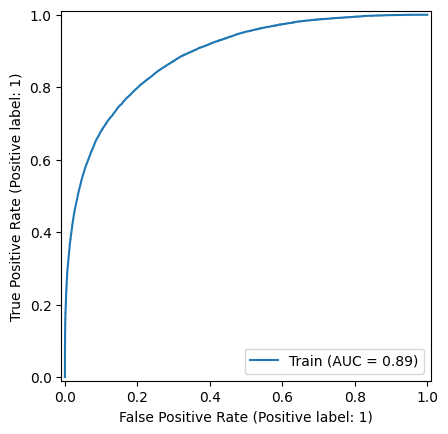

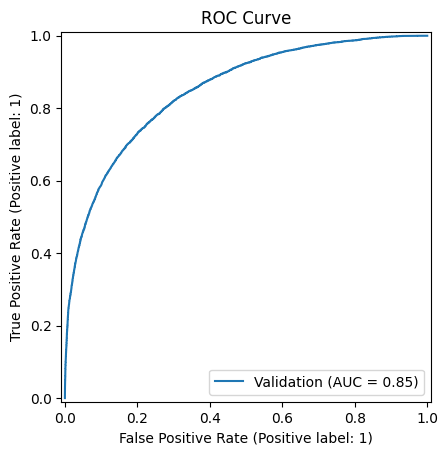

<Figure size 640x480 with 0 Axes>

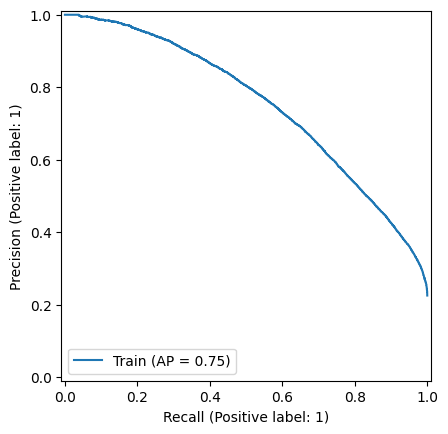

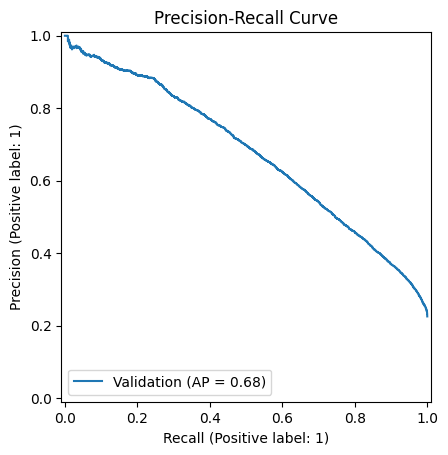

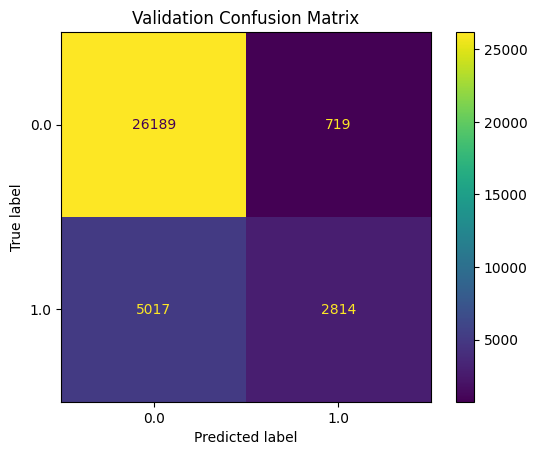

In [24]:
evaluate_model(rf_pipeline , x_train , y_train , x_val , y_val)

In [25]:
# XGboost model

from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ('preprocessor' , preprocessor) ,
    ('model' , XGBClassifier(random_state=42 , n_jobs=-1 , max_depth=10 , n_estimators=100))
])

TRAIN RESULTS
---------------
Accuracy = 0.9735
Precision = 0.9833
Recall = 0.8976
F1 Score = 0.9385
ROC-AUC = 0.9964

VALIDATION RESULTS
---------------
Accuracy = 0.8486
Precision = 0.7239
Recall = 0.5305
F1 Score = 0.6123
ROC-AUC = 0.8726

TRAIN CONFUSION MATRIX
[[76365   340]
 [ 2282 20001]]

VALIDATION CONFUSION MATRIX
[[25324  1584]
 [ 3677  4154]]


<Figure size 640x480 with 0 Axes>

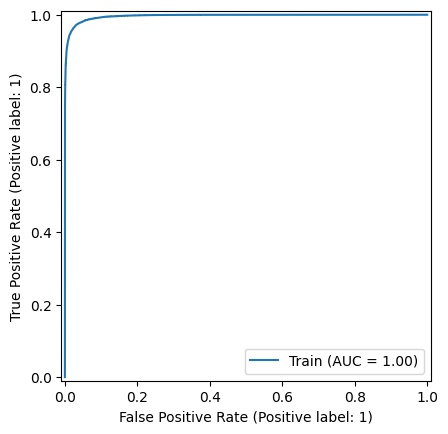

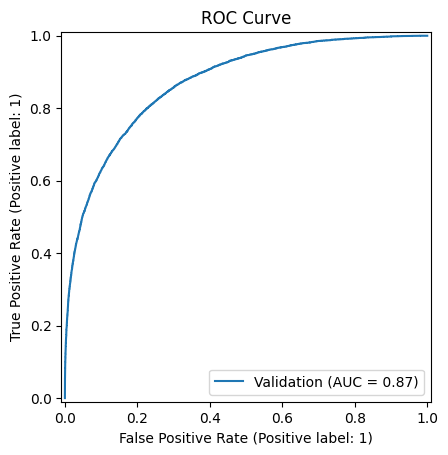

<Figure size 640x480 with 0 Axes>

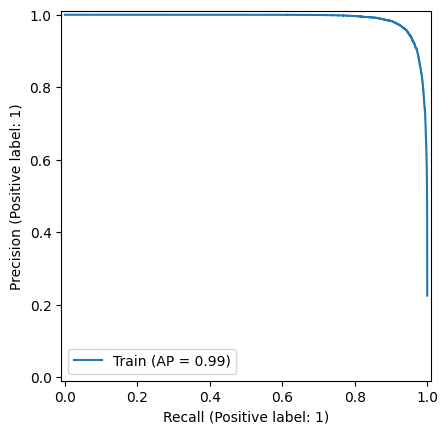

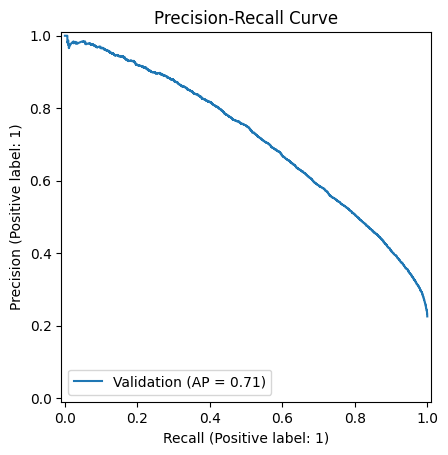

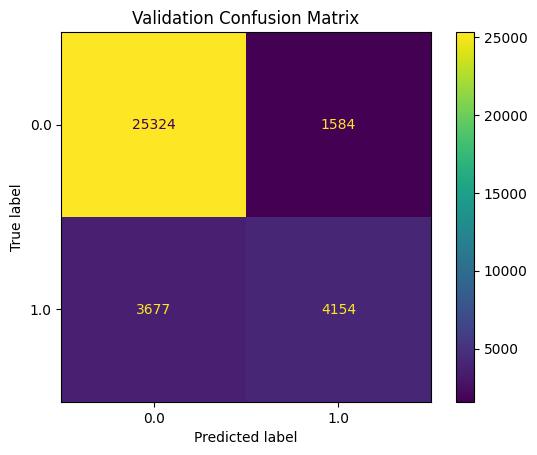

In [26]:
evaluate_model(xgb_pipeline , x_train , y_train , x_val , y_val)

In [27]:
# Gradient Boosting Model 

from sklearn.ensemble import GradientBoostingClassifier

grb_pipeline = Pipeline([
    ('preprocessor' , preprocessor) ,
    ('model' , GradientBoostingClassifier(random_state=42  , max_depth=10 , n_estimators=100 ))
])



TRAIN RESULTS
---------------
Accuracy = 0.9486
Precision = 0.9701
Recall = 0.7962
F1 Score = 0.8746
ROC-AUC = 0.9841

VALIDATION RESULTS
---------------
Accuracy = 0.8503
Precision = 0.7345
Recall = 0.5260
F1 Score = 0.6130
ROC-AUC = 0.8779

TRAIN CONFUSION MATRIX
[[76159   546]
 [ 4541 17742]]

VALIDATION CONFUSION MATRIX
[[25419  1489]
 [ 3712  4119]]


<Figure size 640x480 with 0 Axes>

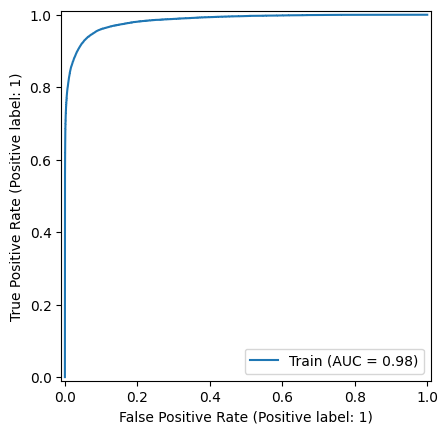

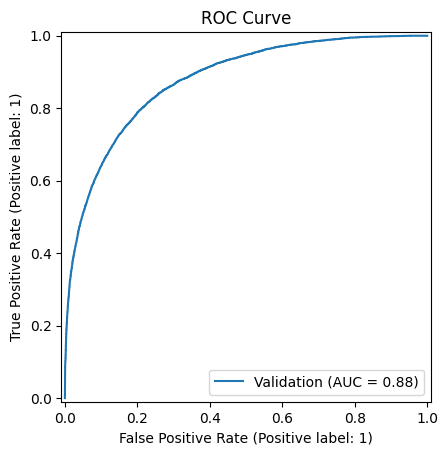

<Figure size 640x480 with 0 Axes>

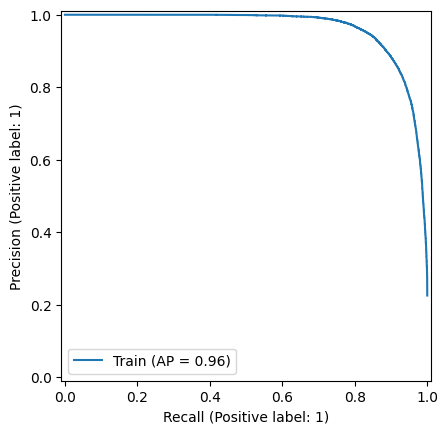

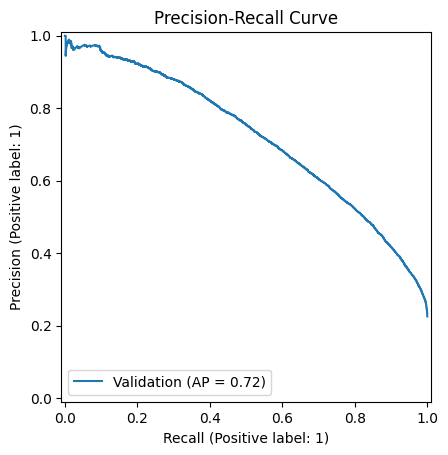

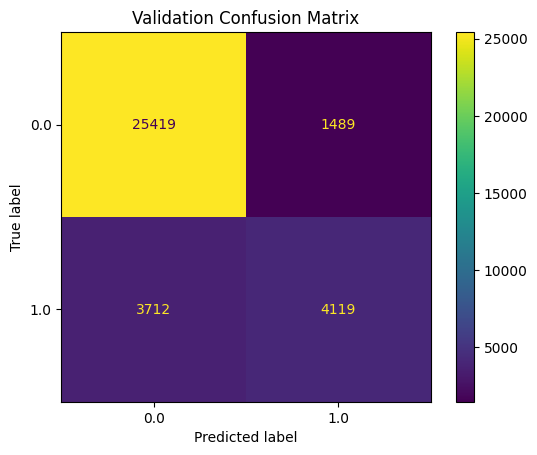

In [74]:
evaluate_model(grb_pipeline , x_train , y_train , x_val , y_val)

In [29]:
# Decision Tree Model

from sklearn.tree import DecisionTreeClassifier

dctree_pipeline = Pipeline([
    ('preprocessor' , preprocessor) ,
    ('model' , DecisionTreeClassifier(random_state=42  , max_depth=10  ))
])


TRAIN RESULTS
---------------
Accuracy = 0.8652
Precision = 0.7914
Recall = 0.5445
F1 Score = 0.6451
ROC-AUC = 0.8872

VALIDATION RESULTS
---------------
Accuracy = 0.8304
Precision = 0.6934
Recall = 0.4443
F1 Score = 0.5416
ROC-AUC = 0.8237

TRAIN CONFUSION MATRIX
[[73507  3198]
 [10150 12133]]

VALIDATION CONFUSION MATRIX
[[25370  1538]
 [ 4352  3479]]


<Figure size 640x480 with 0 Axes>

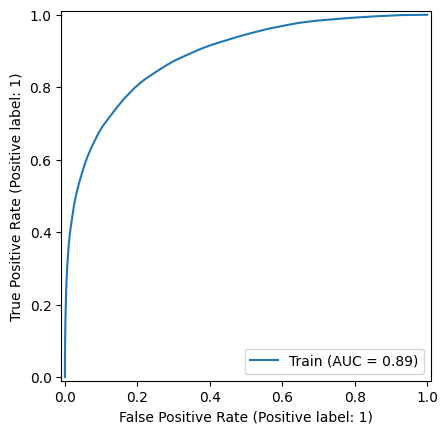

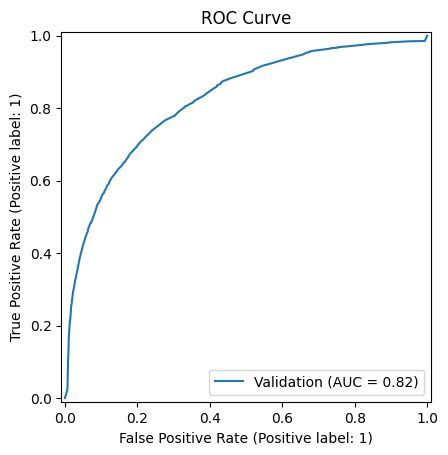

<Figure size 640x480 with 0 Axes>

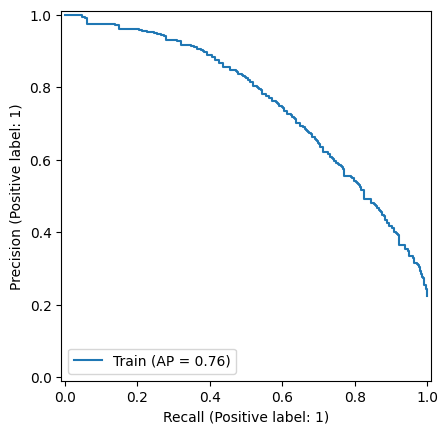

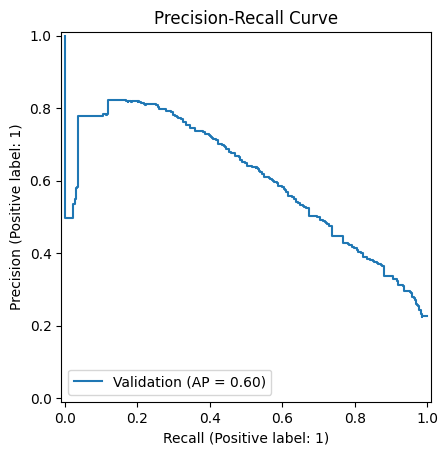

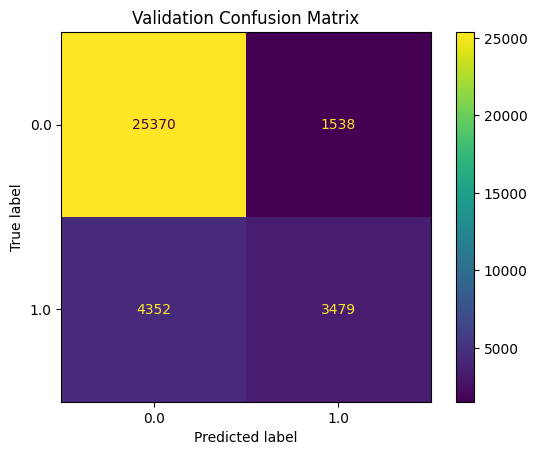

In [30]:
evaluate_model(dctree_pipeline , x_train , y_train , x_val , y_val)

In [ ]:
# AdaBoost

from sklearn.ensemble import AdaBoostClassifier

adaboost_pipeline = Pipeline([
    ('preprocessor' , preprocessor) ,
    ('model' , AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=10) , n_estimators=200 , random_state=42 , learning_rate=0.8))
])


TRAIN RESULTS
---------------
Accuracy = 0.9993
Precision = 1.0000
Recall = 0.9969
F1 Score = 0.9984
ROC-AUC = 1.0000

VALIDATION RESULTS
---------------
Accuracy = 0.8428
Precision = 0.7043
Recall = 0.5216
F1 Score = 0.5994
ROC-AUC = 0.8618

TRAIN CONFUSION MATRIX
[[76705     0]
 [   69 22214]]

VALIDATION CONFUSION MATRIX
[[25193  1715]
 [ 3746  4085]]


<Figure size 640x480 with 0 Axes>

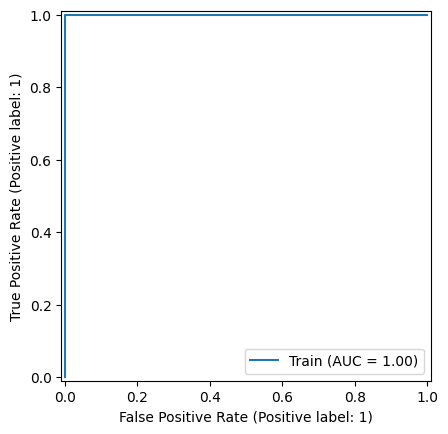

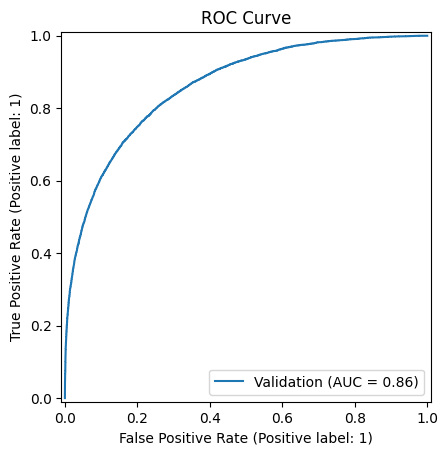

<Figure size 640x480 with 0 Axes>

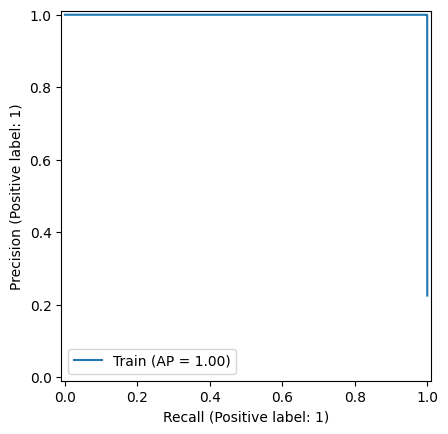

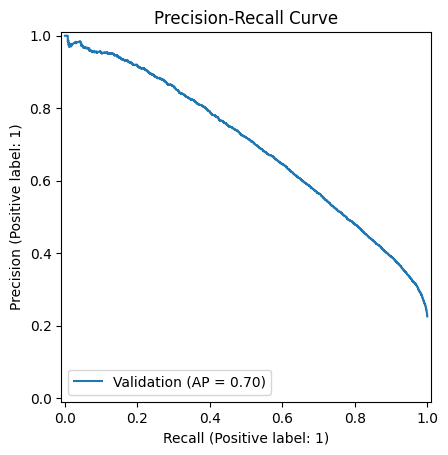

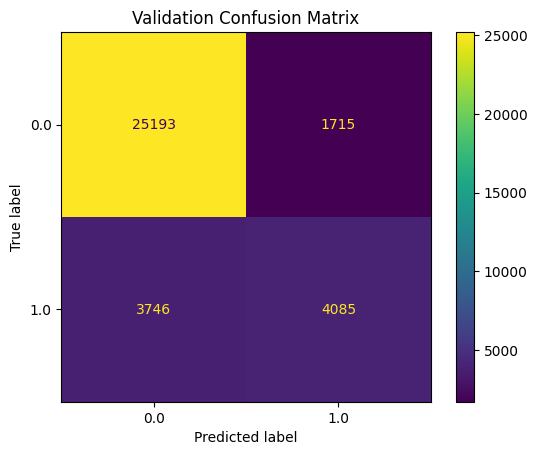

In [75]:
evaluate_model(adaboost_pipeline , x_train , y_train , x_val , y_val)

In [35]:
# HYPER-PARAMETER TUNING

def test_xgb_params( model , x_train , y_train , x_val , y_val):
    model.fit(x_train , y_train)
    y_val_pred = model.predict(x_val)
    y_val_prob = model.predict_proba(x_val)[:,1]
    y_train_pred = model.predict(x_train)
    y_train_prob = model.predict_proba(x_train)[:,1]

    train_accuracy = accuracy_score(y_train , y_train_pred)
    val_accuracy = accuracy_score(y_val , y_val_pred)

    train_precision = precision_score(y_train , y_train_pred)
    val_precision = precision_score(y_val , y_val_pred)

    train_recall = recall_score(y_train , y_train_pred)
    val_recall = recall_score(y_val , y_val_pred)

    train_f1 = f1_score(y_train , y_train_pred)
    val_f1 = f1_score(y_val , y_val_pred)

    train_roc_auc = roc_auc_score(y_train , y_train_prob)
    val_roc_auc = roc_auc_score(y_val , y_val_prob) 



    return val_roc_auc , train_roc_auc ,  val_f1 , train_f1 , val_recall , train_recall , val_precision ,train_precision ,val_accuracy , train_accuracy

# , confusion_matrix(y_val , y_val_pred)


In [36]:
n_estimators_values = [50 , 100 , 200 , 300 , 400 ,500]
results = []
for n in n_estimators_values:

    xgb_pipeline = Pipeline([
    ('preprocessor' , preprocessor) ,
    ('model' , XGBClassifier(random_state=42, n_jobs=-1 , max_depth=10 , n_estimators=n , learning_rate = 0.05 ,subsample=0.7 ,min_child_weight = 1, 
                            colsample_bytree = 0.7, reg_alpha = 0.1, reg_lambda = 1 ))
    ])

    val_roc_auc , train_roc_auc ,  val_f1 , train_f1 , val_recall , train_recall , val_precision ,train_precision , val_accuracy , train_accuracy = test_xgb_params(xgb_pipeline ,  x_train , y_train , x_val , y_val )
    
    results.append({
        'n_estimators' : n ,
        'val_roc_auc' : val_roc_auc ,
        'train_roc_auc' : train_roc_auc ,
        'val_f1' : val_f1 ,
        'train_f1' : train_f1 , 
        'val_recall' : val_recall ,
        'train_recall' : train_recall ,
        'val_precision' : val_precision ,
        'train_precision' : train_precision ,
        'val_accuracy' : val_accuracy ,
        'train_accuracy' : train_accuracy
    })
results = pd.DataFrame(results)    
results

,n_estimators,val_roc_auc,train_roc_auc,val_f1,train_f1,val_recall,train_recall,val_precision,train_precision,val_accuracy,train_accuracy
0,50,0.872232,0.933418,0.571980,0.691840,0.454093,0.572275,0.772540,0.874563,0.846800,0.885239
1,100,0.878091,0.947856,0.603788,0.739310,0.500702,0.638200,0.760326,0.878490,0.851867,0.898685
2,200,0.882932,0.969309,0.616822,0.800728,0.518325,0.710946,0.761538,0.916464,0.854832,0.920344
3,300,0.884479,0.982338,0.623400,0.850919,0.528668,0.772158,0.759494,0.947571,0.856012,0.939094
4,400,0.885022,0.990509,0.626616,0.890533,0.535436,0.823632,0.755223,0.969263,0.856156,0.954419
5,500,0.884644,0.995270,0.627872,0.922032,0.537352,0.868510,0.755069,0.982585,0.856415,0.966935


In [37]:
max_depth_vals = [3,4,5,6,7,8,10]
results = []
for depth in max_depth_vals:

    xgb_pipeline = Pipeline([
    ('preprocessor' , preprocessor) ,
    ('model' , XGBClassifier(random_state=42, n_jobs=-1 , max_depth=depth , n_estimators=200 , learning_rate = 0.05 ,subsample=0.7 ,min_child_weight = 1, 
                            colsample_bytree = 0.7, reg_alpha = 0.1, reg_lambda = 1 ))
    ])

    val_roc_auc , train_roc_auc ,  val_f1 , train_f1 , val_recall , train_recall , val_precision ,train_precision , val_accuracy , train_accuracy = test_xgb_params(xgb_pipeline ,  x_train , y_train , x_val , y_val )
    
    results.append({
        'max_depth' : depth ,
        'val_roc_auc' : val_roc_auc ,
        'train_roc_auc' : train_roc_auc ,
        'val_f1' : val_f1 ,
        'train_f1' : train_f1 , 
        'val_recall' : val_recall ,
        'train_recall' : train_recall ,
        'val_precision' : val_precision ,
        'train_precision' : train_precision ,
        'val_accuracy' : val_accuracy ,
        'train_accuracy' : train_accuracy
    })
results = pd.DataFrame(results)    
results

,max_depth,val_roc_auc,train_roc_auc,val_f1,train_f1,val_recall,train_recall,val_precision,train_precision,val_accuracy,train_accuracy
0,3,0.863479,0.879473,0.569960,0.607758,0.460094,0.507293,0.748753,0.757844,0.843490,0.852598
1,4,0.869466,0.888360,0.578852,0.621518,0.470821,0.521608,0.751222,0.768768,0.845563,0.856993
2,5,0.874030,0.898594,0.588566,0.639345,0.481165,0.539784,0.757692,0.783941,0.848355,0.862913
3,6,0.877617,0.910685,0.600031,0.663985,0.495978,0.566620,0.759335,0.801753,0.850946,0.870904
4,7,0.880497,0.925589,0.608067,0.691338,0.504406,0.594399,0.765356,0.826057,0.853421,0.880521
5,8,0.881354,0.939427,0.609982,0.720637,0.507981,0.623794,0.763239,0.853075,0.853565,0.891128
6,10,0.882932,0.969309,0.616822,0.800728,0.518325,0.710946,0.761538,0.916464,0.854832,0.920344


In [38]:
learning_rate_vals = [0.03 , 0.05 , 0.1 , 0.15]
results = []
for lr in learning_rate_vals:
    xgb_pipeline = Pipeline([
    ('preprocessor' , preprocessor) ,
    ('model' , XGBClassifier(random_state=42, n_jobs=-1 , max_depth=7 , n_estimators=200 , learning_rate = lr ,subsample=0.7 ,min_child_weight = 1, 
                            colsample_bytree = 0.7, reg_alpha = 0.1, reg_lambda = 1 ))
    ])

    val_roc_auc , train_roc_auc ,  val_f1 , train_f1 , val_recall , train_recall , val_precision ,train_precision , val_accuracy , train_accuracy = test_xgb_params(xgb_pipeline ,  x_train , y_train , x_val , y_val )
    
    results.append({
        'learning_rate' : lr ,
        'val_roc_auc' : val_roc_auc ,
        'train_roc_auc' : train_roc_auc ,
        'val_f1' : val_f1 ,
        'train_f1' : train_f1 , 
        'val_recall' : val_recall ,
        'train_recall' : train_recall ,
        'val_precision' : val_precision ,
        'train_precision' : train_precision ,
        'val_accuracy' : val_accuracy ,
        'train_accuracy' : train_accuracy
    })
results = pd.DataFrame(results)    
results

,learning_rate,val_roc_auc,train_roc_auc,val_f1,train_f1,val_recall,train_recall,val_precision,train_precision,val_accuracy,train_accuracy
0,0.03,0.875388,0.911401,0.591602,0.659875,0.483080,0.558138,0.763009,0.806969,0.849650,0.870479
1,0.05,0.880497,0.925589,0.608067,0.691338,0.504406,0.594399,0.765356,0.826057,0.853421,0.880521
2,0.10,0.882465,0.946308,0.614814,0.742283,0.518835,0.651842,0.754363,0.861864,0.853450,0.898109
3,0.15,0.881439,0.960130,0.618024,0.777797,0.526753,0.692366,0.747553,0.887279,0.853220,0.910949


In [39]:
subsample_vals = [0.7 , 0.8 , 0.9]
results = []
for sv in subsample_vals:
    xgb_pipeline = Pipeline([
    ('preprocessor' , preprocessor) ,
    ('model' , XGBClassifier(random_state=42, n_jobs=-1 , max_depth=7 , n_estimators=200 , learning_rate = 0.10 ,subsample=sv ,min_child_weight = 1, 
                            colsample_bytree = 0.7, reg_alpha = 0.1, reg_lambda = 1 ))
    ])

    val_roc_auc , train_roc_auc ,  val_f1 , train_f1 , val_recall , train_recall , val_precision ,train_precision , val_accuracy , train_accuracy = test_xgb_params(xgb_pipeline ,  x_train , y_train , x_val , y_val )
    
    results.append({
        'subsample_vals' : sv ,
        'val_roc_auc' : val_roc_auc ,
        'train_roc_auc' : train_roc_auc ,
        'val_f1' : val_f1 ,
        'train_f1' : train_f1 , 
        'val_recall' : val_recall ,
        'train_recall' : train_recall ,
        'val_precision' : val_precision ,
        'train_precision' : train_precision ,
        'val_accuracy' : val_accuracy ,
        'train_accuracy' : train_accuracy
    })
results = pd.DataFrame(results)    
results

,subsample_vals,val_roc_auc,train_roc_auc,val_f1,train_f1,val_recall,train_recall,val_precision,train_precision,val_accuracy,train_accuracy
0,0.7,0.882465,0.946308,0.614814,0.742283,0.518835,0.651842,0.754363,0.861864,0.853450,0.898109
1,0.8,0.882620,0.946998,0.614906,0.740131,0.517303,0.647893,0.757905,0.862992,0.853939,0.897584
2,0.9,0.883023,0.948389,0.618617,0.744137,0.524454,0.652919,0.753993,0.864982,0.854227,0.898927


In [40]:
min_child_weight_vals = [1,3,5]
results = []
for mcw in min_child_weight_vals:
    xgb_pipeline = Pipeline([
    ('preprocessor' , preprocessor) ,
    ('model' , XGBClassifier(random_state=42, n_jobs=-1 , max_depth=7 , n_estimators=200 , learning_rate = 0.10 ,subsample=0.7 ,min_child_weight = mcw, 
                            colsample_bytree = 0.7, reg_alpha = 0.1, reg_lambda = 1 ))
    ])

    val_roc_auc , train_roc_auc ,  val_f1 , train_f1 , val_recall , train_recall , val_precision ,train_precision , val_accuracy , train_accuracy = test_xgb_params(xgb_pipeline ,  x_train , y_train , x_val , y_val )
    
    results.append({
        'min_child_weight_vals' : mcw ,
        'val_roc_auc' : val_roc_auc ,
        'train_roc_auc' : train_roc_auc ,
        'val_f1' : val_f1 ,
        'train_f1' : train_f1 , 
        'val_recall' : val_recall ,
        'train_recall' : train_recall ,
        'val_precision' : val_precision ,
        'train_precision' : train_precision ,
        'val_accuracy' : val_accuracy ,
        'train_accuracy' : train_accuracy
    })
results = pd.DataFrame(results)    
results

,min_child_weight_vals,val_roc_auc,train_roc_auc,val_f1,train_f1,val_recall,train_recall,val_precision,train_precision,val_accuracy,train_accuracy
0,1,0.882465,0.946308,0.614814,0.742283,0.518835,0.651842,0.754363,0.861864,0.853450,0.898109
1,3,0.881843,0.940983,0.617267,0.731326,0.521772,0.641072,0.755547,0.851159,0.854141,0.893967
2,5,0.882348,0.937726,0.616701,0.721878,0.520112,0.630570,0.757345,0.844107,0.854256,0.890623


In [41]:
colsample_bytree_vals = [0.7 , 0.8 , 0.9 , 1]
results = []
for csb in colsample_bytree_vals:
    xgb_pipeline = Pipeline([
    ('preprocessor' , preprocessor) ,
    ('model' , XGBClassifier(random_state=42, n_jobs=-1 , max_depth=7 , n_estimators=200 , learning_rate = 0.10 ,subsample=0.7 ,min_child_weight = 5, 
                            colsample_bytree = csb, reg_alpha = 0.1, reg_lambda = 1 ))
    ])

    val_roc_auc , train_roc_auc ,  val_f1 , train_f1 , val_recall , train_recall , val_precision ,train_precision , val_accuracy , train_accuracy = test_xgb_params(xgb_pipeline ,  x_train , y_train , x_val , y_val )
    
    results.append({
        'colsample_bytree_vals' : csb ,
        'val_roc_auc' : val_roc_auc ,
        'train_roc_auc' : train_roc_auc ,
        'val_f1' : val_f1 ,
        'train_f1' : train_f1 , 
        'val_recall' : val_recall ,
        'train_recall' : train_recall ,
        'val_precision' : val_precision ,
        'train_precision' : train_precision ,
        'val_accuracy' : val_accuracy ,
        'train_accuracy' : train_accuracy
    })
results = pd.DataFrame(results)    
results

,colsample_bytree_vals,val_roc_auc,train_roc_auc,val_f1,train_f1,val_recall,train_recall,val_precision,train_precision,val_accuracy,train_accuracy
0,0.7,0.882348,0.937726,0.616701,0.721878,0.520112,0.630570,0.757345,0.844107,0.854256,0.890623
1,0.8,0.882424,0.937377,0.613968,0.723558,0.519218,0.633353,0.751016,0.843726,0.852817,0.891058
2,0.9,0.883280,0.938384,0.621701,0.724122,0.527902,0.633846,0.756035,0.844383,0.855177,0.891280
3,1.0,0.883384,0.939334,0.617121,0.726264,0.523816,0.637481,0.750869,0.843778,0.853479,0.891825


In [42]:
reg_alpha_vals = [0 , 0.1 , 1 , 1.5]
results = []
for rgalpha in reg_alpha_vals:
    xgb_pipeline = Pipeline([
    ('preprocessor' , preprocessor) ,
    ('model' , XGBClassifier(random_state=42, n_jobs=-1 , max_depth=7 , n_estimators=200 , learning_rate = 0.10 ,subsample=0.7 ,min_child_weight = 5, 
                            colsample_bytree = 0.9, reg_alpha = rgalpha, reg_lambda = 1 ))
    ])

    val_roc_auc , train_roc_auc ,  val_f1 , train_f1 , val_recall , train_recall , val_precision ,train_precision , val_accuracy , train_accuracy = test_xgb_params(xgb_pipeline ,  x_train , y_train , x_val , y_val )
    
    results.append({
        'reg_alpha_vals' : rgalpha ,
        'val_roc_auc' : val_roc_auc ,
        'train_roc_auc' : train_roc_auc ,
        'val_f1' : val_f1 ,
        'train_f1' : train_f1 , 
        'val_recall' : val_recall ,
        'train_recall' : train_recall ,
        'val_precision' : val_precision ,
        'train_precision' : train_precision ,
        'val_accuracy' : val_accuracy ,
        'train_accuracy' : train_accuracy
    })
results = pd.DataFrame(results)    
results

,reg_alpha_vals,val_roc_auc,train_roc_auc,val_f1,train_f1,val_recall,train_recall,val_precision,train_precision,val_accuracy,train_accuracy
0,0.0,0.883151,0.938675,0.621140,0.725847,0.527902,0.635731,0.754380,0.845731,0.854832,0.891896
1,0.1,0.883280,0.938384,0.621701,0.724122,0.527902,0.633846,0.756035,0.844383,0.855177,0.891280
2,1.0,0.883300,0.937665,0.619792,0.724237,0.526242,0.634564,0.753796,0.843424,0.854458,0.891219
3,1.5,0.882599,0.936603,0.617894,0.720262,0.522539,0.630840,0.755818,0.839224,0.854314,0.889694


In [43]:
reg_lambda_vals = [1 , 5 , 10 ]
results = []
for rglamda in reg_alpha_vals:
    xgb_pipeline = Pipeline([
    ('preprocessor' , preprocessor) ,
    ('model' , XGBClassifier(random_state=42, n_jobs=-1 , max_depth=7 , n_estimators=200 , learning_rate = 0.10 ,subsample=0.7 ,min_child_weight = 5, 
                            colsample_bytree = 0.9, reg_alpha = 0.1, reg_lambda = rglamda ))
    ])

    val_roc_auc , train_roc_auc ,  val_f1 , train_f1 , val_recall , train_recall , val_precision ,train_precision , val_accuracy , train_accuracy = test_xgb_params(xgb_pipeline ,  x_train , y_train , x_val , y_val )
    
    results.append({
        'reg_lambda_vals' : rglamda ,
        'val_roc_auc' : val_roc_auc ,
        'train_roc_auc' : train_roc_auc ,
        'val_f1' : val_f1 ,
        'train_f1' : train_f1 , 
        'val_recall' : val_recall ,
        'train_recall' : train_recall ,
        'val_precision' : val_precision ,
        'train_precision' : train_precision ,
        'val_accuracy' : val_accuracy ,
        'train_accuracy' : train_accuracy
    })
results = pd.DataFrame(results)    
results

,reg_lambda_vals,val_roc_auc,train_roc_auc,val_f1,train_f1,val_recall,train_recall,val_precision,train_precision,val_accuracy,train_accuracy
0,0.0,0.884219,0.939551,0.619642,0.729688,0.523305,0.639636,0.759451,0.849252,0.855177,0.893320
1,0.1,0.883229,0.939127,0.621536,0.726700,0.527008,0.636674,0.757387,0.846379,0.855321,0.892199
2,1.0,0.883280,0.938384,0.621701,0.724122,0.527902,0.633846,0.756035,0.844383,0.855177,0.891280
3,1.5,0.883434,0.937611,0.620378,0.723473,0.525986,0.633084,0.756057,0.843972,0.854889,0.891058


In [51]:
xgb_final_pipeline = Pipeline([
    ('preprocessor' , preprocessor) ,
    ('model' , XGBClassifier(random_state=42, n_jobs=-1 , max_depth=7 , n_estimators=200 , learning_rate = 0.10 ,subsample=0.7 ,min_child_weight = 5, 
                            colsample_bytree = 0.9, reg_alpha = 0.1, reg_lambda = 1.5 ))
])

In [66]:
xgb_final_pipeline.fit(x_train , y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

TRAIN RESULTS
---------------
Accuracy = 0.8911
Precision = 0.8440
Recall = 0.6331
F1 Score = 0.7235
ROC-AUC = 0.9376

VALIDATION RESULTS
---------------
Accuracy = 0.8549
Precision = 0.7561
Recall = 0.5260
F1 Score = 0.6204
ROC-AUC = 0.8834

TRAIN CONFUSION MATRIX
[[74097  2608]
 [ 8176 14107]]

VALIDATION CONFUSION MATRIX
[[25579  1329]
 [ 3712  4119]]


<Figure size 640x480 with 0 Axes>

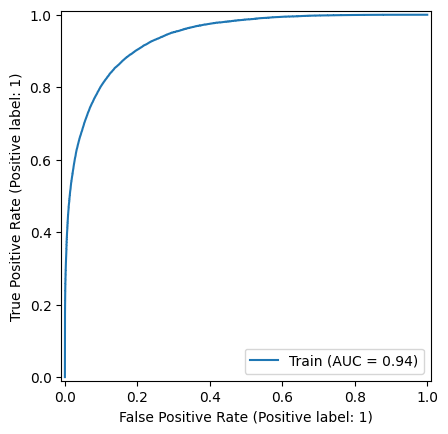

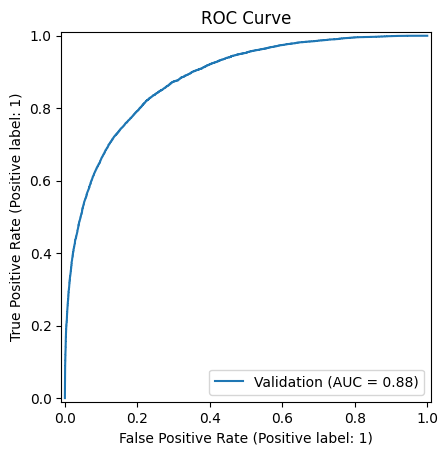

<Figure size 640x480 with 0 Axes>

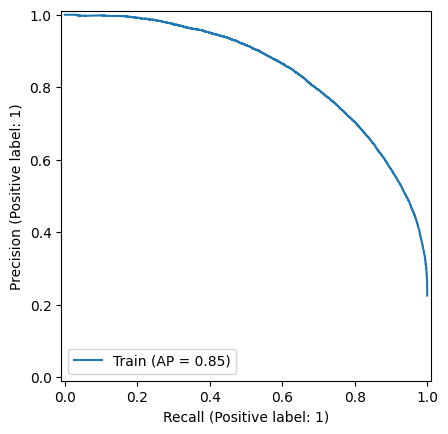

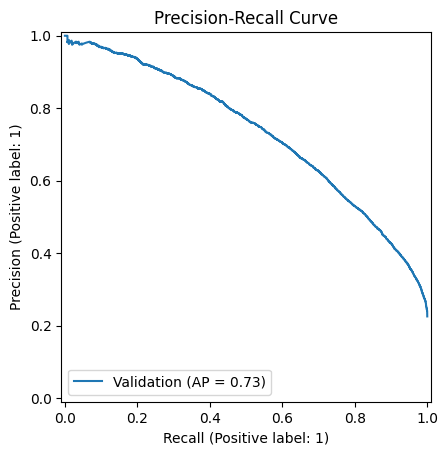

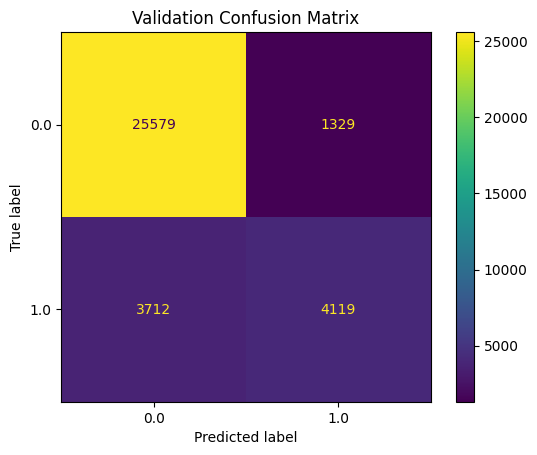

In [52]:
evaluate_model(xgb_final_pipeline,x_train , y_train , x_val , y_val)

In [46]:
# Prediction on Test Set

In [54]:
y_test_pred = xgb_final_pipeline.predict(x_test)
y_test_proba = xgb_final_pipeline.predict_proba(x_test)[:,1]

In [55]:
print("      FINAL TEST RESULTS")
print("-"*30)
print("ROC AUC SCORE = " , roc_auc_score(y_test , y_test_proba))
print("F1 SCORE = " , f1_score(y_test , y_test_pred))
print("Recall SCORE = " , recall_score(y_test , y_test_pred))
print("Precision SCORE = " , precision_score(y_test , y_test_pred))
print("Accuracy SCORE = " , accuracy_score(y_test , y_test_pred))
print("\nConfusion Matrix = ")
print(confusion_matrix(y_test , y_test_pred))
print("\nClassification report = ")
print(classification_report(y_test , y_test_pred))

      FINAL TEST RESULTS
------------------------------
ROC AUC SCORE =  0.8769977869053815
F1 SCORE =  0.5902872777017784
Recall SCORE =  0.4895065229722065
Precision SCORE =  0.7433247200689062
Accuracy SCORE =  0.8584927947082447

Confusion Matrix = 
[[6405  298]
 [ 900  863]]

Classification report = 
              precision    recall  f1-score   support

         0.0       0.88      0.96      0.91      6703
         1.0       0.74      0.49      0.59      1763

    accuracy                           0.86      8466
   macro avg       0.81      0.72      0.75      8466
weighted avg       0.85      0.86      0.85      8466



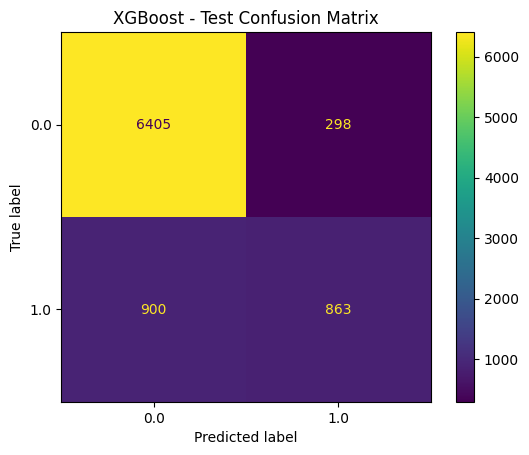

In [70]:
# Graphs
# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(y_test , y_test_pred)
plt.title("XGBoost - Test Confusion Matrix")
plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

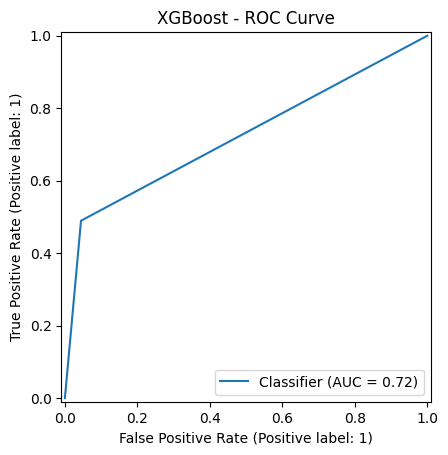

In [69]:
# ROC Curve

RocCurveDisplay.from_predictions(y_test , y_test_pred)
plt.title("XGBoost - ROC Curve")
plt.savefig("images/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [64]:
# Feature Importance


feature_names = xgb_final_pipeline.named_steps["preprocessor"].get_feature_names_out()
model = xgb_final_pipeline.named_steps["model"]
importances = model.feature_importances_

In [65]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
9,num__Humidity3pm,0.082383
2,num__Rainfall,0.022028
13,num__Cloud3pm,0.020220
4,num__Sunshine,0.019958
5,num__WindGustSpeed,0.019206
69,cat__Location_Witchcliffe,0.014573
11,num__Pressure3pm,0.013977
23,cat__Location_Adelaide,0.012398
70,cat__Location_Wollongong,0.012232
46,cat__Location_MountGinini,0.011907


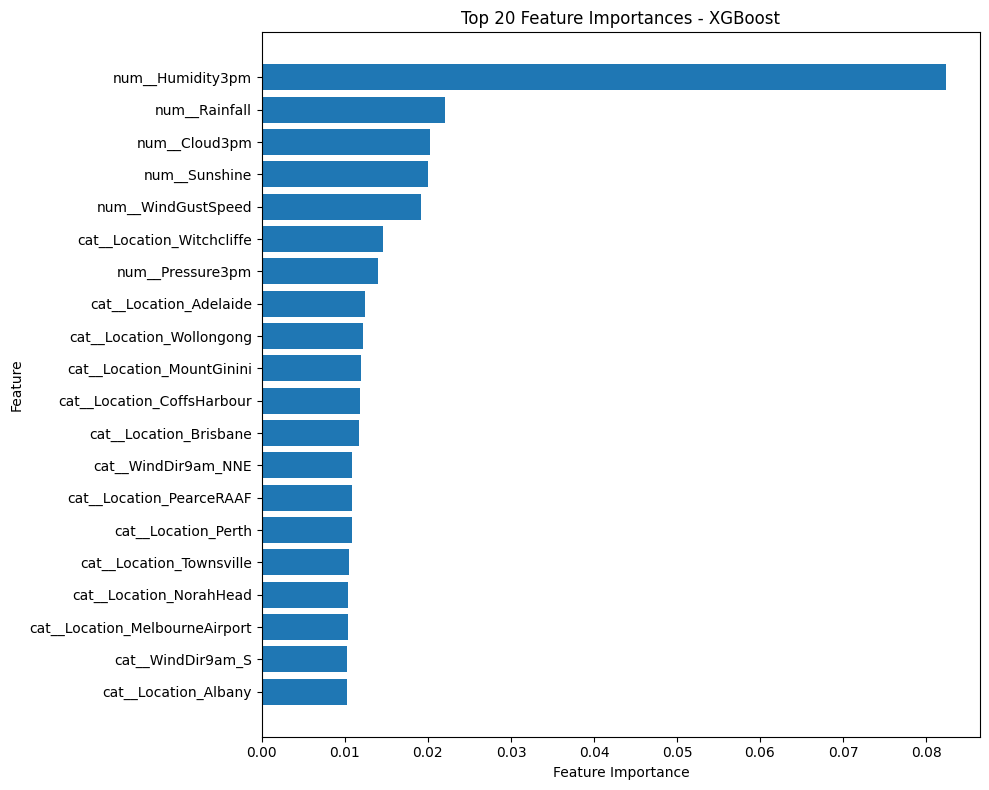

In [68]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances - XGBoost")

plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [76]:
# FINAL COMPARISON TABLE BETWEEN ALL MODELS

In [77]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting",
        "XGBoost"
    ],

    "Accuracy": [
        0.8304,
        0.8349,
        0.8391,
        0.8503,
        0.8549   # tuned XGBoost validation
    ],

    "Precision": [
        0.6934,
        0.7965,
        0.6835,
        0.7345,
        0.7561
    ],

    "Recall": [
        0.4443,
        0.3593,
        0.5331,
        0.5260,
        0.5268
    ],

    "F1": [
        0.5416,
        0.4952,
        0.5990,
        0.6130,
        0.6264
    ],

    "ROC-AUC": [
        0.8237,
        0.8504,
        0.8587,
        0.8779,
        0.8834
    ]
})

final_results = final_results.sort_values(
    by="ROC-AUC",
    ascending=False
)

final_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
4,XGBoost,0.8549,0.7561,0.5268,0.6264,0.8834
3,Gradient Boosting,0.8503,0.7345,0.5260,0.6130,0.8779
2,AdaBoost,0.8391,0.6835,0.5331,0.5990,0.8587
1,Random Forest,0.8349,0.7965,0.3593,0.4952,0.8504
0,Decision Tree,0.8304,0.6934,0.4443,0.5416,0.8237


In [78]:
# GRAPH OF FINAL COMPARISON TABLE BETWEEN ALL MODELS

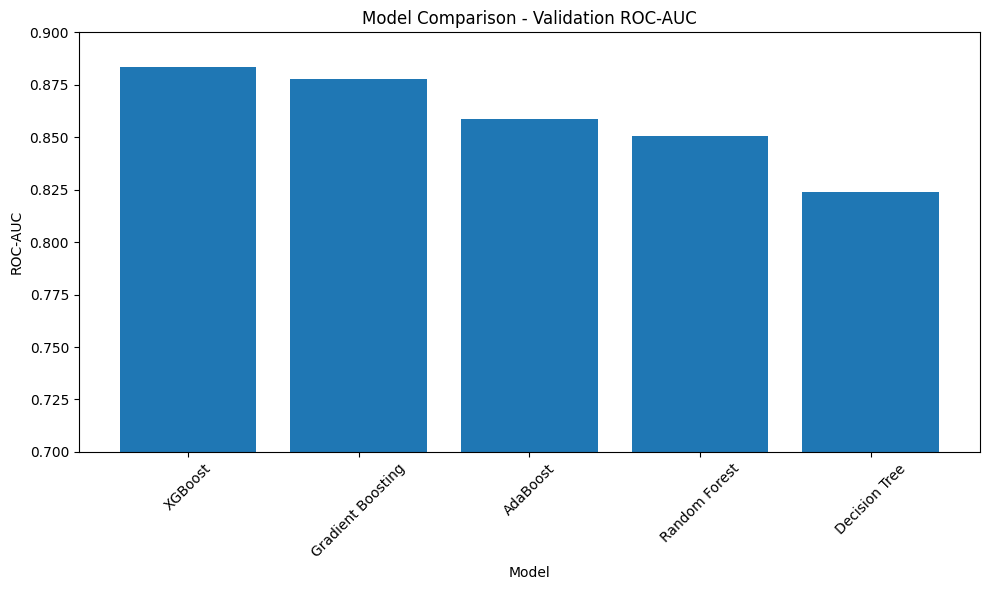

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    final_results["Model"],
    final_results["ROC-AUC"]
)

plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.title("Model Comparison - Validation ROC-AUC")
plt.xticks(rotation=45)
plt.ylim(0.7, 0.9)

plt.tight_layout()
plt.savefig("images/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()